# `construction_year` 01: basic `year` breakdown

**Purpose:** apply the analysis that is always performed for this feature
type, without mixing in cross-feature interpretation.

**Current role:** `candidate`

**Provisional disposition:** derive valid pump age and retain unknown-year state


## Standard checks for `year`

        Every predictor with this audit type receives the same basic checks:

        - numeric range and zero-year sentinel
- construction cohorts
- valid age relative to date_recorded
- training/test coverage

        This notebook stays descriptive. Target interpretation belongs in notebook 02,
        and cross-feature relationships belong in notebook 03.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def find_stage_directory():
    start = Path.cwd().resolve()
    for candidate in (start, *start.parents):
        if (
            (candidate / "data" / "TrainingSetValues.csv").exists()
            and (candidate / "src" / "source_data_validation.py").exists()
        ):
            return candidate
    raise FileNotFoundError("Could not locate the stage-1-pump-it-up directory.")


stage_directory = find_stage_directory()
source_directory = str((stage_directory / "src").resolve())
if source_directory not in sys.path:
    sys.path.insert(0, source_directory)

from predictor_audit import (
    analysis_categories,
    categorical_summary,
    categorical_target_profile,
    category_frequency_table,
    numeric_summary,
    numeric_target_summary,
    related_feature_summary,
    sentinel_mask,
    source_blank_mask,
    text_normalisation_summary,
)
from source_data_validation import (
    validate_aligned_ids,
    validate_label_frame,
    validate_raw_feature_schema,
)

data_directory = stage_directory / "data"
training_features = pd.read_csv(
    data_directory / "TrainingSetValues.csv",
    keep_default_na=False,
)
training_labels = pd.read_csv(
    data_directory / "TrainingSetLabels.csv",
    keep_default_na=False,
)
test_features = pd.read_csv(
    data_directory / "TestSetValues.csv",
    keep_default_na=False,
)

validate_raw_feature_schema(training_features)
validate_raw_feature_schema(test_features)
validate_label_frame(training_labels)
validate_aligned_ids(training_features, training_labels)

training_data = training_features.merge(
    training_labels,
    on="id",
    validate="one_to_one",
)

feature = 'construction_year'
feature_metadata = {'order': 23, 'name': 'construction_year', 'audit_type': 'year', 'role': 'candidate', 'disposition': 'derive valid pump age and retain unknown-year state', 'finding': 'Year zero affects about a third of rows and a small number of derived ages are negative.', 'decision': 'Keep unknown and inconsistent flags plus valid pump age or construction cohort.', 'risk': 'Age is missing for many rows and is confounded with technology and geography.', 'sentinel_values': [0], 'related': [{'feature': 'date_recorded', 'reason': 'Together they define waterpoint age at observation.'}, {'feature': 'installer', 'reason': 'Installers operate in particular construction cohorts.'}, {'feature': 'extraction_type', 'reason': 'Extraction technology changes across construction cohorts.'}, {'feature': 'gps_height', 'reason': 'Year and height zeros frequently share one measurement block.'}]}
feature_types = {'amount_tsh': 'numeric', 'date_recorded': 'date', 'funder': 'high-cardinality-category', 'gps_height': 'numeric', 'installer': 'high-cardinality-category', 'longitude': 'coordinate', 'latitude': 'coordinate', 'wpt_name': 'high-cardinality-category', 'num_private': 'numeric', 'basin': 'category', 'subvillage': 'high-cardinality-category', 'region': 'category', 'region_code': 'category', 'district_code': 'category', 'lga': 'category', 'ward': 'high-cardinality-category', 'population': 'numeric', 'public_meeting': 'binary', 'recorded_by': 'constant', 'scheme_management': 'category', 'scheme_name': 'high-cardinality-category', 'permit': 'binary', 'construction_year': 'year', 'extraction_type': 'category', 'extraction_type_group': 'category', 'extraction_type_class': 'category', 'management': 'category', 'management_group': 'category', 'payment': 'category', 'payment_type': 'category', 'water_quality': 'category', 'quality_group': 'category', 'quantity': 'category', 'quantity_group': 'category', 'source': 'category', 'source_type': 'category', 'source_class': 'category', 'waterpoint_type': 'category', 'waterpoint_type_group': 'category'}
assert feature in training_features.columns
print(
    f"Validated {len(training_features):,} training rows and "
    f"{len(test_features):,} test rows for {feature}."
)


Validated 59,400 training rows and 14,850 test rows for construction_year.


## Distribution, sentinels and coverage


In [2]:
sentinel_values = [0]
summary = numeric_summary(
    training_features,
    test_features,
    [feature],
    sentinel_values_by_column={feature: sentinel_values},
)
display(summary)


rows  missing  sentinel rows  zero rows  \
feature           frame                                                
construction_year training  59400        0          20709      20709   
                  test      14850        0           5260       5260   

                            negative rows  unique  minimum  p01  median  \
feature           frame                                                   
construction_year training              0      55        0  0.0  1986.0   
                  test                  0      55        0  0.0  1986.0   

                                mean     p99  maximum  skewness  
feature           frame                                          
construction_year training  1300.652  2012.0     2013    -0.635  
                  test      1289.708  2012.0     2013    -0.609

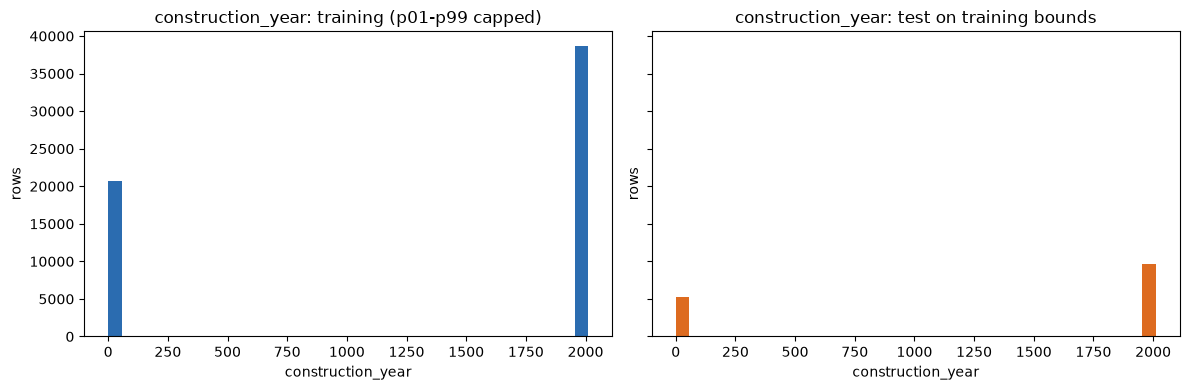

,training rows,test rows
construction_year,,
0,20709,5260
1995,0,269
2000,2091,487
2002,1075,268
2003,1286,293
2004,1123,294
2006,1471,421
2007,1587,373
2008,2613,630


In [3]:
training_values = pd.to_numeric(training_features[feature], errors="coerce")
test_values = pd.to_numeric(test_features[feature], errors="coerce")
lower = training_values.quantile(0.01)
upper = training_values.quantile(0.99)
bins = np.linspace(lower, upper, 36)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)
axes[0].hist(training_values.clip(lower, upper), bins=bins, color="#2b6cb0")
axes[0].set_title(f"{feature}: training (p01-p99 capped)")
axes[1].hist(test_values.clip(lower, upper), bins=bins, color="#dd6b20")
axes[1].set_title(f"{feature}: test on training bounds")
for axis in axes:
    axis.set_xlabel(feature)
    axis.set_ylabel("rows")
plt.tight_layout()
plt.show()

top_values = pd.DataFrame({
    "training rows": training_values.value_counts().head(12),
    "test rows": test_values.value_counts().head(12),
}).fillna(0).astype(int)
display(top_values)


## Basic-breakdown handoff

The outputs above establish shape, missingness, support and supplied
train/test coverage. They do not by themselves establish usefulness or a
causal explanation. Notebook 02 interprets noteworthy single-feature
evidence; notebook 03 tests the explicitly related predictors.
